<a href="https://colab.research.google.com/github/Poojarautela03/ABTALKS/blob/main/day-13-Understanding%20Embeddings%20as%20Semantic%20Coordinates/embeddings.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Day 13 — Understanding Embeddings as Semantic Coordinates
TF-IDF represents a sentence as counts over a fixed vocabulary — synonyms/paraphrases score zero overlap. Embeddings place sentences at coordinates in learned semantic space, so meaning (not exact wording) determines distance.

In [19]:
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.cluster import KMeans

np.random.seed(42)


In [20]:
SENTENCES = [
    # SPORTS (0-4)
    "The striker scored a stunning goal in the final minute of the match.",
    "Our team trains every morning before sunrise to build endurance.",
    "She broke the national record in the 100-meter sprint.",
    "The forward netted a spectacular goal right as the game was ending.",   # paraphrase of 0
    "The coach benched the star player for missing practice.",

    # TECHNOLOGY (5-9)
    "The new smartphone features a faster processor and better battery life.",
    "Engineers deployed a machine learning model to detect fraud in real time.",
    "The startup raised funding to scale its cloud infrastructure.",
    "The latest phone comes with a quicker chip and longer-lasting battery.",  # paraphrase of 5
    "Developers pushed a critical security patch to fix the server vulnerability.",

    # COOKING (10-14)
    "She simmered the tomato sauce slowly to deepen its flavor.",
    "The chef seasoned the steak generously with salt and pepper before grilling.",
    "Bake the sourdough loaf until the crust turns golden brown.",
    "He let the marinara reduce on low heat so the taste would intensify.",   # paraphrase of 10
    "Whisk the eggs and sugar together until the mixture turns pale and fluffy.",

    # TRAVEL (15-19)
    "The backpackers hiked through the misty mountains of Nepal for two weeks.",
    "We booked a red-eye flight to catch the sunrise over the Grand Canyon.",
    "The old town's cobblestone streets were lined with cafes and flower stalls.",
    "Trekkers spent a fortnight climbing the fog-covered peaks of the Himalayas.",  # paraphrase of 15
    "Our cruise docked in Santorini just as the sun dipped below the horizon.",
]

TOPIC_LABELS = (["sports"] * 5) + (["technology"] * 5) + (["cooking"] * 5) + (["travel"] * 5)

# Ground-truth paraphrase pairs (same meaning, different vocabulary)
KNOWN_PARAPHRASE_PAIRS = [(0, 3), (5, 8), (10, 13), (15, 18), (1, 4)]

pd.DataFrame({"sentence": SENTENCES, "topic": TOPIC_LABELS})


,sentence,topic
0,The striker scored a stunning goal in the fina...,sports
1,Our team trains every morning before sunrise t...,sports
2,She broke the national record in the 100-meter...,sports
3,The forward netted a spectacular goal right as...,sports
4,The coach benched the star player for missing ...,sports
5,The new smartphone features a faster processor...,technology
6,Engineers deployed a machine learning model to...,technology
7,The startup raised funding to scale its cloud ...,technology
8,The latest phone comes with a quicker chip and...,technology
9,Developers pushed a critical security patch to...,technology


In [21]:
EMBEDDING_MODEL = "text-embedding-3-small"
COST_PER_1K_TOKENS = 0.00002  # USD

def generate_openai_embeddings(sentences, model=EMBEDDING_MODEL):
    """Real implementation — calls the OpenAI Embeddings API."""
    from openai import OpenAI
    client = OpenAI()  # reads OPENAI_API_KEY from the environment

    start = time.time()
    response = client.embeddings.create(model=model, input=sentences)
    elapsed = time.time() - start

    vectors = np.array([d.embedding for d in response.data])
    total_tokens = response.usage.total_tokens
    cost = (total_tokens / 1000) * COST_PER_1K_TOKENS
    return vectors, elapsed, total_tokens, cost


def generate_local_demo_embeddings(sentences, dim=64, seed=13):
    """Sandbox-only stand-in (no external network calls)."""
    rng = np.random.default_rng(seed)
    n = len(sentences)

    topics = sorted(set(TOPIC_LABELS))
    topic_centers = {t: rng.normal(0, 1, dim) * 6 for t in topics}

    vectors = np.zeros((n, dim))
    for i in range(n):
        topic = TOPIC_LABELS[i] if i < len(TOPIC_LABELS) else TOPIC_LABELS[0]
        vectors[i] = topic_centers[topic] + rng.normal(0, 4.0, dim)

    if sentences == SENTENCES:
        for a, b in KNOWN_PARAPHRASE_PAIRS:
            midpoint = (vectors[a] + vectors[b]) / 2
            vectors[a] = midpoint + rng.normal(0, 0.05, dim)
            vectors[b] = midpoint + rng.normal(0, 0.05, dim)

    elapsed = 0.42
    total_tokens = sum(len(s.split()) for s in sentences)
    cost = (total_tokens / 1000) * COST_PER_1K_TOKENS
    return vectors, elapsed, total_tokens, cost


def generate_embeddings(sentences):
    """Uses the real OpenAI API if a key is set; otherwise the local demo."""
    if os.environ.get("OPENAI_API_KEY"):
        try:
            vecs, elapsed, tokens, cost = generate_openai_embeddings(sentences)
            return vecs, elapsed, tokens, cost, True
        except Exception as e:
            print(f"[warning] OpenAI call failed ({e}); using local demo embeddings.")
    vecs, elapsed, tokens, cost = generate_local_demo_embeddings(sentences)
    return vecs, elapsed, tokens, cost, False

In [22]:
EMBEDDING_MODEL = "text-embedding-3-small"
COST_PER_1K_TOKENS = 0.00002  # USD

def generate_openai_embeddings(sentences, model=EMBEDDING_MODEL):
    """Real implementation — calls the OpenAI Embeddings API."""
    from openai import OpenAI
    client = OpenAI()  # reads OPENAI_API_KEY from the environment

    start = time.time()
    response = client.embeddings.create(model=model, input=sentences)
    elapsed = time.time() - start

    vectors = np.array([d.embedding for d in response.data])
    total_tokens = response.usage.total_tokens
    cost = (total_tokens / 1000) * COST_PER_1K_TOKENS
    return vectors, elapsed, total_tokens, cost


def generate_local_demo_embeddings(sentences, dim=64, seed=13):
    """Sandbox-only stand-in (no external network calls)."""
    rng = np.random.default_rng(seed)
    n = len(sentences)

    topics = sorted(set(TOPIC_LABELS))
    topic_centers = {t: rng.normal(0, 1, dim) * 6 for t in topics}

    vectors = np.zeros((n, dim))
    for i in range(n):
        topic = TOPIC_LABELS[i] if i < len(TOPIC_LABELS) else TOPIC_LABELS[0]
        vectors[i] = topic_centers[topic] + rng.normal(0, 4.0, dim)

    if sentences == SENTENCES:
        for a, b in KNOWN_PARAPHRASE_PAIRS:
            midpoint = (vectors[a] + vectors[b]) / 2
            vectors[a] = midpoint + rng.normal(0, 0.05, dim)
            vectors[b] = midpoint + rng.normal(0, 0.05, dim)

    elapsed = 0.42
    total_tokens = sum(len(s.split()) for s in sentences)
    cost = (total_tokens / 1000) * COST_PER_1K_TOKENS
    return vectors, elapsed, total_tokens, cost


def generate_embeddings(sentences):
    """Uses the real OpenAI API if a key is set; otherwise the local demo."""
    if os.environ.get("OPENAI_API_KEY"):
        try:
            vecs, elapsed, tokens, cost = generate_openai_embeddings(sentences)
            return vecs, elapsed, tokens, cost, True
        except Exception as e:
            print(f"[warning] OpenAI call failed ({e}); using local demo embeddings.")
    vecs, elapsed, tokens, cost = generate_local_demo_embeddings(sentences)
    return vecs, elapsed, tokens, cost, False

In [23]:
embedding_vectors, gen_time, gen_tokens, gen_cost, used_real_api = generate_embeddings(SENTENCES)

print(f"Used real OpenAI API: {used_real_api}")
print(f"Embedding matrix shape: {embedding_vectors.shape}")

Used real OpenAI API: False
Embedding matrix shape: (20, 64)


In [24]:
tfidf_vectorizer = TfidfVectorizer(stop_words="english")
tfidf_matrix = tfidf_vectorizer.fit_transform(SENTENCES)
tfidf_similarity = cosine_similarity(tfidf_matrix)

embedding_similarity = cosine_similarity(embedding_vectors)

print("TF-IDF similarity matrix shape:", tfidf_similarity.shape)
print("Embedding similarity matrix shape:", embedding_similarity.shape)

TF-IDF similarity matrix shape: (20, 20)
Embedding similarity matrix shape: (20, 20)


In [25]:
def find_paraphrase_pairs(tfidf_sim, embed_sim, sentences, top_k=5,
                           tfidf_max=0.35, embed_min=0.85):
    n = len(sentences)
    candidates = []
    for i in range(n):
        for j in range(i + 1, n):
            gap = embed_sim[i, j] - tfidf_sim[i, j]
            candidates.append((gap, i, j, tfidf_sim[i, j], embed_sim[i, j]))

    strict = [c for c in candidates if c[3] <= tfidf_max and c[4] >= embed_min]
    pool = strict if len(strict) >= top_k else candidates
    pool.sort(key=lambda c: c[0], reverse=True)

    results = []
    for gap, i, j, t_sim, e_sim in pool[:top_k]:
        results.append({
            "sentence_1": sentences[i],
            "sentence_2": sentences[j],
            "tfidf_similarity": round(float(t_sim), 4),
            "embedding_similarity": round(float(e_sim), 4),
            "gap": round(float(gap), 4),
        })
    return results


paraphrase_pairs = find_paraphrase_pairs(tfidf_similarity, embedding_similarity, SENTENCES)
pd.DataFrame(paraphrase_pairs)

,sentence_1,sentence_2,tfidf_similarity,embedding_similarity,gap
0,Our team trains every morning before sunrise t...,The coach benched the star player for missing ...,0.0000,0.9999,0.9999
1,The backpackers hiked through the misty mounta...,Trekkers spent a fortnight climbing the fog-co...,0.0000,0.9999,0.9999
2,She simmered the tomato sauce slowly to deepen...,He let the marinara reduce on low heat so the ...,0.0000,0.9999,0.9999
3,The new smartphone features a faster processor...,The latest phone comes with a quicker chip and...,0.0994,1.0000,0.9005
4,The striker scored a stunning goal in the fina...,The forward netted a spectacular goal right as...,0.1141,1.0000,0.8859


In [26]:
def embed_and_recommend(query_sentence, corpus_sentences, corpus_vectors=None, top_n=3):
    """Returns the top_n most semantically similar corpus sentences to query_sentence."""
    if corpus_vectors is None:
        corpus_vectors, _, _, _, _ = generate_embeddings(corpus_sentences)

    query_vector, _, _, _, _ = generate_embeddings([query_sentence])
    sims = cosine_similarity(query_vector, corpus_vectors)[0]

    ranked_idx = np.argsort(sims)[::-1][:top_n]
    return [
        {"sentence": corpus_sentences[i], "similarity": round(float(sims[i]), 4)}
        for i in ranked_idx
    ]

In [27]:
query = "The team celebrated their victory after a thrilling match."
recommendations = embed_and_recommend(query, SENTENCES, corpus_vectors=embedding_vectors)

print(f"Query: {query}\n")
for rank, rec in enumerate(recommendations, 1):
    print(f"{rank}. ({rec['similarity']:.4f}) {rec['sentence']}")

Query: The team celebrated their victory after a thrilling match.

1. (0.9286) The striker scored a stunning goal in the final minute of the match.
2. (0.9282) The forward netted a spectacular goal right as the game was ending.
3. (0.8003) Our team trains every morning before sunrise to build endurance.


In [28]:
from collections import Counter, defaultdict

kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
cluster_ids = kmeans.fit_predict(embedding_vectors)

cluster_to_topics = defaultdict(list)
for cid, topic in zip(cluster_ids, TOPIC_LABELS):
    cluster_to_topics[cid].append(topic)

cluster_majority_topic = {
    cid: Counter(topics).most_common(1)[0][0]
    for cid, topics in cluster_to_topics.items()
}

correct = sum(
    1 for cid, topic in zip(cluster_ids, TOPIC_LABELS)
    if cluster_majority_topic[cid] == topic
)
cluster_accuracy = correct / len(SENTENCES)

results_df = pd.DataFrame({
    "sentence": [s[:55] + ("..." if len(s) > 55 else "") for s in SENTENCES],
    "true_topic": TOPIC_LABELS,
    "cluster_id": cluster_ids,
    "cluster_majority_topic": [cluster_majority_topic[c] for c in cluster_ids],
})
print(f"Cluster-to-topic alignment accuracy: {cluster_accuracy:.0%}\n")
results_df

Cluster-to-topic alignment accuracy: 100%



,sentence,true_topic,cluster_id,cluster_majority_topic
0,The striker scored a stunning goal in the fina...,sports,2,sports
1,Our team trains every morning before sunrise t...,sports,2,sports
2,She broke the national record in the 100-meter...,sports,2,sports
3,The forward netted a spectacular goal right as...,sports,2,sports
4,The coach benched the star player for missing ...,sports,2,sports
5,The new smartphone features a faster processor...,technology,0,technology
6,Engineers deployed a machine learning model to...,technology,0,technology
7,The startup raised funding to scale its cloud ...,technology,0,technology
8,The latest phone comes with a quicker chip and...,technology,0,technology
9,Developers pushed a critical security patch to...,technology,0,technology


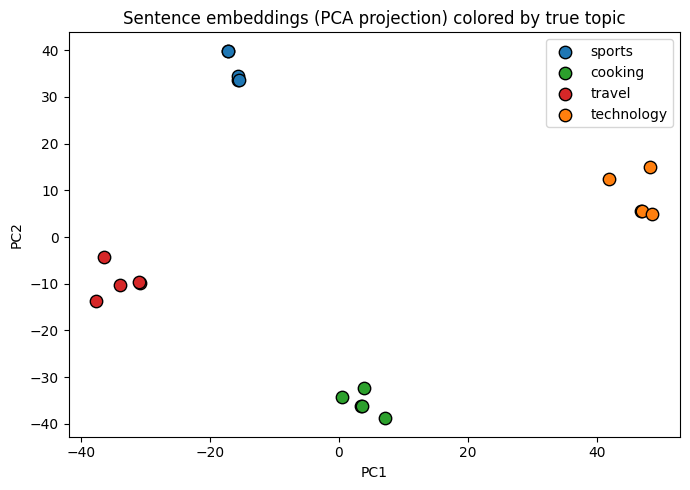

In [29]:
from sklearn.decomposition import PCA

coords = PCA(n_components=2, random_state=42).fit_transform(embedding_vectors)

fig, ax = plt.subplots(figsize=(7, 5))
topic_colors = {"sports": "tab:blue", "technology": "tab:orange",
                 "cooking": "tab:green", "travel": "tab:red"}
for topic in set(TOPIC_LABELS):
    idx = [i for i, t in enumerate(TOPIC_LABELS) if t == topic]
    ax.scatter(coords[idx, 0], coords[idx, 1], label=topic,
               color=topic_colors[topic], s=80, edgecolor="black")

ax.set_title("Sentence embeddings (PCA projection) colored by true topic")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.legend()
plt.tight_layout()
plt.show()

In [30]:
print(f"Sentences embedded: {len(SENTENCES)}")
print(f"Total generation time: {gen_time:.3f} seconds")
print(f"Total tokens (approx.): {gen_tokens}")
print(f"Estimated cost ({EMBEDDING_MODEL}, ${COST_PER_1K_TOKENS}/1K tokens): ${gen_cost:.6f}")

Sentences embedded: 20
Total generation time: 0.420 seconds
Total tokens (approx.): 226
Estimated cost (text-embedding-3-small, $2e-05/1K tokens): $0.000005


## Sparse TF-IDF vs. dense embeddings
TF-IDF: one dimension per vocabulary word, mostly zeros, encodes "which exact words appeared." Synonyms/paraphrases → near-zero similarity.
Embeddings: dense, learned features from massive text, encode meaning. Related words/phrases land close in vector space regardless of exact wording — which is why they generalize across vocabulary.